<a href="https://colab.research.google.com/github/arojocz/machine-learning-Projects/blob/main/gradient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Descenso de gradiente

In [ ]:
DE MANERA SIMBOLICA TENEMOS QUE EL DESCENSO DE GRADIENTE SE HACE DE LA SIGUIENTE MANERA:

In [ ]:
import sympy as sp
import numpy as np

def descenso_gradiente():
    funct_str = input("Ingresa la función (ej: x**2 + 3*x + 2): ")

    x = sp.symbols('x')

    try:
        function = sp.sympify(funct_str)

        # deruvadas
        derivada = sp.diff(function, x)

        f = sp.lambdify(x, function, 'numpy')
        df = sp.lambdify(x, derivada, 'numpy')

    except Exception as e:
        print("Error: La función ingresada no es válida.")
        print("Detalles:", e)
        return

    tasa_aprendizaje = float(input("Ingresa la tasa de aprendizaje (ej: 0.1): "))
    iteraciones = int(input("Ingresa el número de iteraciones (ej: 100): "))
    x_actual = float(input("Ingresa el valor inicial de x (ej: 0): "))

    for i in range(iteraciones):
        gradiente = df(x_actual)
        x_actual -= tasa_aprendizaje * gradiente

        # cada 100 iters
        if i % 100 == 0 or i == iteraciones - 1:
            print(f"Iteración {i}: x = {x_actual:.4f}, f(x) = {f(x_actual):.4f}")

    print("\n--- Resultado ---")
    print(f"x óptimo: {x_actual:.4f}")
    print(f"Valor mínimo de f(x): {f(x_actual):.4f}")

descenso_gradiente()


Ingresa la función (ej: x**2 + 3*x + 2): x**2+2*x+3
Ingresa la tasa de aprendizaje (ej: 0.1): 0.001
Ingresa el número de iteraciones (ej: 100): 10000
Ingresa el valor inicial de x (ej: 0): 44
Iteración 0: x = 43.9100, f(x) = 2018.9081
Iteración 100: x = 35.7618, f(x) = 1353.4325
Iteración 200: x = 29.0920, f(x) = 907.5295
Iteración 300: x = 23.6323, f(x) = 608.7515
Iteración 400: x = 19.1632, f(x) = 408.5548
Iteración 500: x = 15.5049, f(x) = 274.4127
Iteración 600: x = 12.5104, f(x) = 184.5306
Iteración 700: x = 10.0592, f(x) = 124.3049
Iteración 800: x = 8.0527, f(x) = 83.9506
Iteración 900: x = 6.4102, f(x) = 56.9111
Iteración 1000: x = 5.0657, f(x) = 38.7933
Iteración 1100: x = 3.9652, f(x) = 26.6534
Iteración 1200: x = 3.0644, f(x) = 18.5191
Iteración 1300: x = 2.3270, f(x) = 13.0686
Iteración 1400: x = 1.7233, f(x) = 9.4165
Iteración 1500: x = 1.2292, f(x) = 6.9695
Iteración 1600: x = 0.8248, f(x) = 5.3298
Iteración 1700: x = 0.4937, f(x) = 4.2311
Iteración 1800: x = 0.2227, f(x)

# Regresión linear

In [ ]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Cargar datos
data = load_diabetes()
X = data.data
y = data.target

X = np.hstack([np.ones((X.shape[0], 1)), X])

# dividir (70/30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# Inicializar parámetros
m, n = X_train.shape
theta = np.zeros(n)
alpha = 0.005
epochs = 30000

# descenso grad
for epoch in range(epochs):
    predictions = X_train @ theta
    errors = predictions - y_train
    gradient = (1/m) * (X_train.T @ errors)
    theta -= alpha * gradient

    if epoch % 1000 == 0:
        cost = (1/(2*m)) * np.sum(errors**2)
        print(f"Iteración {epoch}: Costo = {cost:.4f}")

# Evaluar en el conjunto de prueba
y_pred = X_test @ theta
mse = mean_squared_error(y_test, y_pred)
print(f"\nError cuadrático medio en test (descenso de gradiente): {mse:.4f}")


Iteración 0: Costo = 14917.1942
Iteración 1000: Costo = 2974.5620
Iteración 2000: Costo = 2884.8025
Iteración 3000: Costo = 2802.2992
Iteración 4000: Costo = 2725.9700
Iteración 5000: Costo = 2655.3045
Iteración 6000: Costo = 2589.8361
Iteración 7000: Costo = 2529.1381
Iteración 8000: Costo = 2472.8201
Iteración 9000: Costo = 2420.5248
Iteración 10000: Costo = 2371.9256
Iteración 11000: Costo = 2326.7235
Iteración 12000: Costo = 2284.6448
Iteración 13000: Costo = 2245.4390
Iteración 14000: Costo = 2208.8770
Iteración 15000: Costo = 2174.7489
Iteración 16000: Costo = 2142.8623
Iteración 17000: Costo = 2113.0414
Iteración 18000: Costo = 2085.1249
Iteración 19000: Costo = 2058.9650
Iteración 20000: Costo = 2034.4264
Iteración 21000: Costo = 2011.3850
Iteración 22000: Costo = 1989.7270
Iteración 23000: Costo = 1969.3482
Iteración 24000: Costo = 1950.1528
Iteración 25000: Costo = 1932.0532
Iteración 26000: Costo = 1914.9686
Iteración 27000: Costo = 1898.8252
Iteración 28000: Costo = 1883.55

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

data = load_diabetes()
X = data.data
y = data.target

X = np.hstack([np.ones((X.shape[0], 1)), X])

# Hold-out 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# descenso grad
theta, history = gradient_descent(X_train, y_train, alpha=0.005, epochs=30000)

# Evaluación
y_pred = X_test @ theta
mse = mean_squared_error(y_test, y_pred)
print(f"\nMSE en test: {mse:.4f}")


Iteración 0: Costo = 14619.5696
Iteración 100: Costo = 7262.4572
Iteración 200: Costo = 4556.5182
Iteración 300: Costo = 3557.4073
Iteración 400: Costo = 3184.6792
Iteración 500: Costo = 3041.8574
Iteración 600: Costo = 2983.4521
Iteración 700: Costo = 2956.0745
Iteración 800: Costo = 2940.1327
Iteración 900: Costo = 2928.4370
Iteración 1000: Costo = 2918.3485
Iteración 1100: Costo = 2908.8985
Iteración 1200: Costo = 2899.7311
Iteración 1300: Costo = 2890.7151
Iteración 1400: Costo = 2881.8020
Iteración 1500: Costo = 2872.9736
Iteración 1600: Costo = 2864.2228
Iteración 1700: Costo = 2855.5465
Iteración 1800: Costo = 2846.9431
Iteración 1900: Costo = 2838.4117
Iteración 2000: Costo = 2829.9516
Iteración 2100: Costo = 2821.5619
Iteración 2200: Costo = 2813.2421
Iteración 2300: Costo = 2804.9915
Iteración 2400: Costo = 2796.8094
Iteración 2500: Costo = 2788.6953
Iteración 2600: Costo = 2780.6485
Iteración 2700: Costo = 2772.6683
Iteración 2800: Costo = 2764.7542
Iteración 2900: Costo = 2

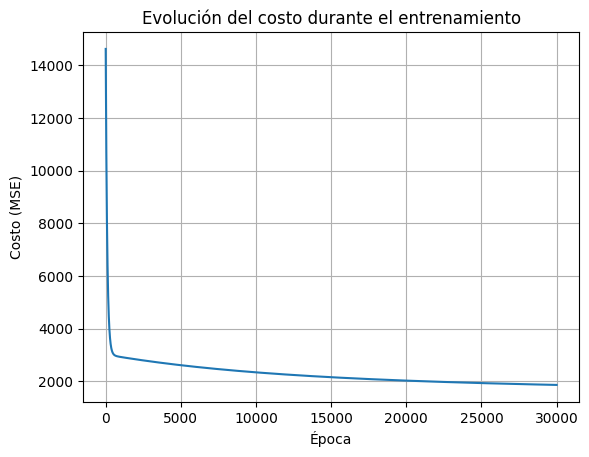

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.xlabel("Época")
plt.ylabel("Costo (MSE)")
plt.title("Evolución del costo durante el entrenamiento")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# Cargar datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
column_names = ['mpg', 'cylinders', 'displacement', 'horsepower',
                'weight', 'acceleration', 'model_year', 'origin', 'car_name']
df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')
df = df.dropna()

# Selección de variables
X = df[['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']].values
y = df['mpg'].values

# Normalización
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Añadir columna de 1s para el término independiente (bias)
X_scaled = np.hstack([np.ones((X_scaled.shape[0], 1)), X_scaled])

# Hold-out 70/30
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=7)

def gradient_descent(X, y, alpha=0.01, epochs=1000):
    m, n = X.shape
    theta = np.zeros(n)
    history = []
    for epoch in range(epochs):
        predictions = X @ theta
        errors = predictions - y
        gradient = (1/m) * (X.T @ errors)
        theta -= alpha * gradient
        cost = (1/(2*m)) * np.sum(errors ** 2)
        history.append(cost)
    return theta, history

# Entrenamiento
theta, history = gradient_descent(X_train, y_train, alpha=0.0005, epochs=30000)

# Evaluación
y_pred = X_test @ theta
mse = mean_squared_error(y_test, y_pred)
print(f"\nMSE en test: {mse:.4f}")


/tmp/ipython-input-27-3395578680.py:11: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(url, names=column_names, delim_whitespace=True, na_values='?')



MSE en test: 16.8396


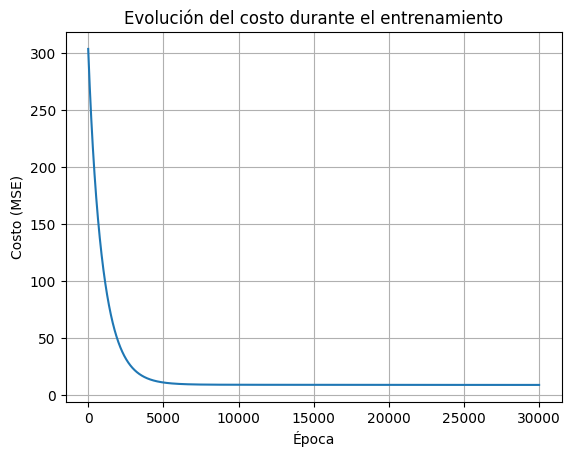

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.xlabel("Época")
plt.ylabel("Costo (MSE)")
plt.title("Evolución del costo durante el entrenamiento")
plt.grid(True)
plt.show()
